# Goal
This notebook will show how to map data using the MapMyCells data products released with the HMBA consensus Basal Ganglia taxonomy.

[Original Notebook here](https://github.com/AllenInstitute/HMBA_BasalGanglia_Consensus_Taxonomy/blob/main/examples/using_MapMyCells_data.ipynb)

# Install MapMyCell dependencies
We are going to start by installing the `cell_type_mapper` (actual backend for MapMyCells) and `abc_atlas_access` (convenient download of other data provided by the AllenInstitute) libraries.
```bash
uv add "cell_type_mapper@git+https://github.com/alleninstitute/cell_type_mapper.git@rc/v1.5.2"
uv add "abc_atlas_access[notebooks] @ git+https://github.com/alleninstitute/abc_atlas_access.git"
```

# Dowload mapping files for basal ganglia

To run MapMyCells, you need two supporting data files: 
- [an HDF5 file](https://github.com/AllenInstitute/cell_type_mapper/blob/main/docs/input_data_files/precomputed_stats_file.md) which defines your taxonomy and the average gene expression profiles of the taxons there in
- [lookup table of marker genes](https://github.com/AllenInstitute/cell_type_mapper/blob/main/docs/input_data_files/marker_gene_lookup.md) for your taxonomy. 

Let's download those two files for the **human** basal ganglia data. 
Refer back [to the main page](https://github.com/AllenInstitute/HMBA_BasalGanglia_Consensus_Taxonomy/blob/main/index.md#cell-type-mapping-with-mapmycells) for the locations of the relevant files for all three species (human, marmoset, and macaque).

```bash
wget https://released-taxonomies-802451596237-us-west-2.s3.us-west-2.amazonaws.com/HMBA/BasalGanglia/BICAN_05072025_pre-print_release/MapMyCells/Human.precomputed_stats.20250507.h5
wget https://released-taxonomies-802451596237-us-west-2.s3.us-west-2.amazonaws.com/HMBA/BasalGanglia/BICAN_05072025_pre-print_release/MapMyCells/Human.query_markers.20250507.json
```

---

In [65]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
from dotenv import load_dotenv; load_dotenv()

# MUST BE FIRST - before any imports from cell_type_mapper --> error if FromSpecifiedMarkersRunner run wiht GPU
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import cell_type_mapper
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from cell_type_mapper.cli.from_specified_markers import FromSpecifiedMarkersRunner

# Hyperparamyters
BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")
DISEASE_TYPE = "diseased" # diseased / healthy
SAMPLE_ID = "sample_03"
BCL = "260313_SL-EXA_0758_B23GHNHLT4"#"251027_SL-EXD_0706_A233KGFLT4", "FAKE_BCL", "260313_SL-EXA_0758_B23GHNHLT4"
LIBRARY = "SI-TT-C5"#"SI-TT-H3"

# Prepare Query data

Your query data must be:
- **Format**: `.h5ad` file (AnnData format)
- **Structure**: 
  - `X` layer with **RAW** gene expression data (cells × genes)
  - `obs` with cell metadata
  - `var` with gene names, **Ensembl IDs** for MapMyCells-supported taxonomies

In [66]:
# FIXED (always mappign againf basal ganglia)
query_marker_path = os.getenv("ALLEN_ATLAS_BG_MMC_MARKER_JSON") # the lookup table of marker genes which we downloaded from S3
precomputed_path = os.getenv("ALLEN_ATLAS_BG_MMC_STAT_H5") # the human-specific precomputed stats file which we downloaded from S3

In [67]:
QUERY_PATH = f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/adata/raw_adata.h5ad"

# paths to files where mapping output will be written
json_dst_path = str(Path(QUERY_PATH).parent.parent / "map_my_cell" / "mapping.json")
csv_dst_path = str(Path(QUERY_PATH).parent.parent / "map_my_cell" / "mapping.csv")

# saving adata path
adata_labelled_path = str(Path(QUERY_PATH).parent / "labelled_adata.h5ad")

In [68]:
# # ONLY IF YOU WANT TO SPECIFIY

# if True:
#     QUERY_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all.h5ad"

#     # paths to files where mapping output will be written
#     json_dst_path = f"{os.path.split(QUERY_PATH)[0]}/map_my_cell/mapping.json"
#     csv_dst_path = f"{os.path.split(QUERY_PATH)[0]}/map_my_cell/mapping.csv"
#     os.makedirs(f"{os.path.split(QUERY_PATH)[0]}/map_my_cell", exist_ok=True)

#     # saving adata path
#     adata_labelled_path = f"{os.path.split(QUERY_PATH)[0]}/NucSeq_all_labelled.h5ad"

# adata_labelled_path


In [69]:
os.path.split(QUERY_PATH)[0]

'/home/gdallagl/myworkdir/data/XDP/diseased/sample_03/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C5/adata'

# Run Mapping

Now we will actually [perform the mapping](https://github.com/AllenInstitute/cell_type_mapper/blob/main/docs/mapping_cells.md).

In [70]:
config = {
    # output paths
    "query_path": QUERY_PATH,
    "extended_result_path": json_dst_path,
    "csv_result_path": csv_dst_path,
    "verbose_csv": True,

    # inout paths
    "query_markers": {
       "serialized_lookup": query_marker_path
    },
    "precomputed_stats": {
        "path": precomputed_path
    },

    "type_assignment": {
        "n_processors": 16,
        "normalization": "raw", # Use raw counts (not normalized)
        "bootstrap_factor": 0.5,
        "bootstrap_iteration": 100
    }
}

In [71]:
runner = FromSpecifiedMarkersRunner(
    args=[],
    input_data=config
)
runner.run()
print("Done!")

=== Running Hierarchical Mapping 1.5.2 with config ===
{
  "obsm_clobber": false,
  "verbose_csv": true,
  "verbose_stdout": true,
  "hdf5_result_path": null,
  "query_markers": {
    "log_level": "ERROR",
    "collapse_markers": false,
    "serialized_lookup": "/home/gdallagl/myworkdir/XDP/data/AllenAtlas/BGT_human_20250507/Human.query_markers.20250507.json"
  },
  "query_gene_id_col": null,
  "nodes_to_drop": null,
  "drop_level": null,
  "type_assignment": {
    "rng_seed": 11235813,
    "min_markers": 10,
    "chunk_size": 10000,
    "n_runners_up": 5,
    "n_processors": 16,
    "log_level": "ERROR",
    "bootstrap_factor": 0.5,
    "normalization": "raw",
    "bootstrap_iteration": 100,
    "bootstrap_factor_lookup": null
  },
  "precomputed_stats": {
    "path": "/home/gdallagl/myworkdir/XDP/data/AllenAtlas/BGT_human_20250507/Human.precomputed_stats.20250507.h5",
    "log_level": "ERROR"
  },
  "max_gb": 100.0,
  "cloud_safe": false,
  "extended_result_dir": null,
  "log_level":

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/cell_type_mapper/cli/cli_log.py:73: UserWarning: numpy's internal parallelization is enabled. This could cause independent worker processes to compete for resources, degrading performance. We recommend setting the following environment variables to '1' to improve performance
{
  "NUMEXPR_NUM_THREADS": "",
  "MKL_NUM_THREADS": "",
  "OMP_NUM_THREADS": ""
}
  warnings.warn(msg)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/cell_type_mapper/cli/cli_log.py:104: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  self.env(f"anndata version: {anndata.__version__}")
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/cell_type_mapper/taxonomy/utils.py:253: UserWarning: This taxonomy has no mapping from leaf_node -> rows in the cell by gene matrix
  warnings.warn("This taxonomy has no mapping from leaf_node -> rows "
/home/gdallagl/myworkdir/XDP/.venv/lib

BENCHMARK: spent 1.5698e-01 seconds creating query marker cache
Running CPU implementation of type assignment.
BENCHMARK: spent 3.8493e+02 seconds assigning cell types
Writing marker genes to output file
MAPPING FROM SPECIFIED MARKERS RAN SUCCESSFULLY
CLEANING UP
Done!


# Output of mapping file

The results of our mapping are now in two files: the csv file pointed to by `csv_dst_path` and the JSON file pointed to by `json_dst_path`. Dedicated documentation of the the contents of the mapping output [can be found here.](https://github.com/AllenInstitute/cell_type_mapper/blob/main/docs/output.md)

## CSV output file

The CSV file is effectively just a dataframe. For every cell at every taxonomy level, you have its assigned cell type (both as a guaranteed unique "label" and a more human readable "name") along with quality metrics assessing the confidence in the mapping (see the detailed documentation above).

In [72]:
mapping_csv = pd.read_csv(csv_dst_path, comment='#')
mapping_csv = mapping_csv.set_index("cell_id")

display(mapping_csv)

,Neighborhood_label,Neighborhood_name,Neighborhood_bootstrapping_probability,Neighborhood_aggregate_probability,Neighborhood_correlation_coefficient,Class_label,Class_name,Class_bootstrapping_probability,Class_aggregate_probability,Class_correlation_coefficient,...,Group_name,Group_bootstrapping_probability,Group_aggregate_probability,Group_correlation_coefficient,Cluster_label,Cluster_name,Cluster_alias,Cluster_bootstrapping_probability,Cluster_aggregate_probability,Cluster_correlation_coefficient
cell_id,,,,,,,,,,,,,,,,,,,,,
AAACCAAAGATCTTCC-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.7268,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.7002,...,STRv D1 MSN,0.95,0.9500,0.4558,CS20250428_CLUST_0529,Human-166,Human-166,0.26,0.2470,0.3708
AAACCAAAGCGGGGAT-1,CS20250428_NEIGH_0002,Subpallium GABA,0.86,0.86,0.4929,CS20250428_CLASS_0006,F M GABA,0.52,0.4472,0.4575,...,SN-VTR-HTH GATA3-TCF7L2 GABA,1.00,0.1744,0.5068,CS20250428_CLUST_0359,Human-524,Human-524,0.56,0.0977,0.2665
AAACCAAAGCTATAAC-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.7826,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.7507,...,STRd D2 Matrix MSN,1.00,1.0000,0.6510,CS20250428_CLUST_0468,Human-433,Human-433,0.59,0.5900,0.4392
AAACCAAAGGGAAGCC-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.8513,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.8431,...,STRd D1 Matrix MSN,0.99,0.9900,0.6250,CS20250428_CLUST_0435,Human-26,Human-26,0.95,0.9405,0.4722
AAACCAAAGGTCGCCA-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.8435,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.8290,...,STRd D1 Matrix MSN,1.00,1.0000,0.6551,CS20250428_CLUST_0443,Human-512,Human-512,0.87,0.8700,0.4888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTGCAGGGGTTTC-1,CS20250428_NEIGH_0001,Nonneuron,1.00,1.00,0.7954,CS20250428_CLASS_0010,OPC-Oligo,1.00,1.0000,0.9212,...,Oligo PLEKHG1,1.00,1.0000,0.7096,CS20250428_CLUST_0231,Human-15,Human-15,1.00,1.0000,0.7994
GTTGTGGGTACCTTTG-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.7873,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.7658,...,STRd D2 Striosome MSN,1.00,1.0000,0.6065,CS20250428_CLUST_0492,Human-477,Human-477,0.95,0.9500,0.4132
GTTGTGGGTAGCTTGG-1,CS20250428_NEIGH_0002,Subpallium GABA,1.00,1.00,0.7708,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.0000,0.7528,...,STRv D2 MSN,1.00,1.0000,0.6080,CS20250428_CLUST_0552,Human-339,Human-339,0.94,0.9400,0.5810


# Add Metadata to adata and Save

In [73]:
# Read adata
query_adata = sc.read_h5ad(QUERY_PATH)

# Merge metadata
query_adata.obs = query_adata.obs.join(mapping_csv, how="left")
display(query_adata.obs)

# save 
query_adata.write(adata_labelled_path)


n_cells_original = len(query_adata.obs)
n_cells_mapped = mapping_csv.index.nunique()
print(f"Original cells: {n_cells_original}")
print(f"Mapped cells: {n_cells_mapped}")
assert n_cells_original == n_cells_mapped, "Mapping incomplete!"

,x,y,pct_intronic,dbscan_clusters,dbscan_score,sample,has_spatial,Neighborhood_label,Neighborhood_name,Neighborhood_bootstrapping_probability,...,Group_name,Group_bootstrapping_probability,Group_aggregate_probability,Group_correlation_coefficient,Cluster_label,Cluster_name,Cluster_alias,Cluster_bootstrapping_probability,Cluster_aggregate_probability,Cluster_correlation_coefficient
AAACCAAAGATCTTCC-1,56619.529584,-4189.466489,0.579186,1,0.989543,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRv D1 MSN,0.95,0.9500,0.4558,CS20250428_CLUST_0529,Human-166,Human-166,0.26,0.2470,0.3708
AAACCAAAGCGGGGAT-1,59079.248719,-7905.161983,0.709032,1,0.969148,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,0.86,...,SN-VTR-HTH GATA3-TCF7L2 GABA,1.00,0.1744,0.5068,CS20250428_CLUST_0359,Human-524,Human-524,0.56,0.0977,0.2665
AAACCAAAGCTATAAC-1,17571.123540,4042.299494,0.704688,1,0.868196,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRd D2 Matrix MSN,1.00,1.0000,0.6510,CS20250428_CLUST_0468,Human-433,Human-433,0.59,0.5900,0.4392
AAACCAAAGGGAAGCC-1,43466.374328,3490.945493,0.699606,3,0.565402,sample_03,False,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRd D1 Matrix MSN,0.99,0.9900,0.6250,CS20250428_CLUST_0435,Human-26,Human-26,0.95,0.9405,0.4722
AAACCAAAGGTCGCCA-1,43466.129636,6578.568382,0.768053,1,0.951560,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRd D1 Matrix MSN,1.00,1.0000,0.6551,CS20250428_CLUST_0443,Human-512,Human-512,0.87,0.8700,0.4888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTGCAGGGGTTTC-1,49025.385004,7114.528950,0.572950,1,0.854783,sample_03,True,CS20250428_NEIGH_0001,Nonneuron,1.00,...,Oligo PLEKHG1,1.00,1.0000,0.7096,CS20250428_CLUST_0231,Human-15,Human-15,1.00,1.0000,0.7994
GTTGTGGGTACCTTTG-1,49048.766487,6021.088118,0.743793,1,0.963434,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRd D2 Striosome MSN,1.00,1.0000,0.6065,CS20250428_CLUST_0492,Human-477,Human-477,0.95,0.9500,0.4132
GTTGTGGGTAGCTTGG-1,52843.607615,-8956.517652,0.611910,1,0.704430,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRv D2 MSN,1.00,1.0000,0.6080,CS20250428_CLUST_0552,Human-339,Human-339,0.94,0.9400,0.5810
GTTGTGGGTCCTGCGC-1,50047.710918,-3143.292426,0.612490,1,0.932391,sample_03,True,CS20250428_NEIGH_0002,Subpallium GABA,1.00,...,STRd D1 Striosome MSN,0.67,0.4422,0.5372,CS20250428_CLUST_0444,Human-23,Human-23,1.00,0.4422,0.5222


Original cells: 11488
Mapped cells: 11488


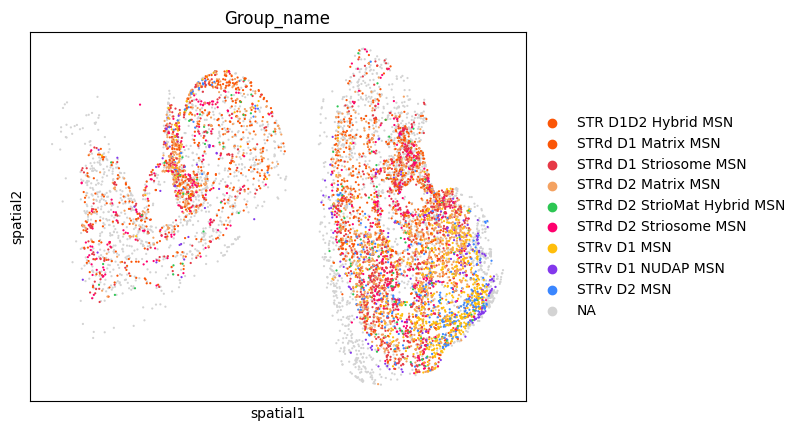

In [74]:
sc.pl.embedding(query_adata, basis="spatial",  color="Group_name", 
                groups=["STRd D1 Matrix MSN", "STRd D1 Striosome MSN", "STRd D2 Matrix MSN", "STRd D2 Striosome MSN", "STRd D2 StrioMat Hybrid MSN", "STRv D1 MSN", "STRv D2 MSN", "STRv D1 NUDAP MSN", "STR D1D2 Hybrid MSN"],
                size=10, palette = ["#E63946", "#F4A261", "#2DC653", "#FF006E", "#FFBE0B", "#8338EC", "#3A86FF", "#06D6A0", "#FB5607"]
)

---
---
---

## Optional: JSON output file

The JSON output contains everything in the CSV file, along with helpful metadata about your mapping run as [documented here](https://github.com/AllenInstitute/cell_type_mapper/blob/main/docs/output.md#json-output-file).

In [75]:
# with open(json_dst_path, 'rb') as src:
#     mapping_json = json.load(src)

For instance, to see the configuration parameters corresponding to your mapping run, you can look at

In [76]:
# print(json.dumps(mapping_json['config'], indent=2))

The actual cell type assignments are stored as a list under `'results'` as in

In [77]:
# print(json.dumps(mapping_json['results'][0], indent=2))

One complication is that the cell type assignments are only referred to by their unique machine-readable labels in this file. Fortunately, the cell type taxonomy, along with the mapping between machine- and human-readable cell type labels is also provided in this file. The `TaxonomyTree` class provides a helpful interface with that data.

In [78]:
# from cell_type_mapper.taxonomy.taxonomy_tree import TaxonomyTree

In [79]:
# taxonomy = TaxonomyTree(data=mapping_json['taxonomy_tree'])

In [80]:
# taxonomy.label_to_name(level='CCN20250428_LEVEL_3', label='CS20250428_GROUP_0025')